# Preliminary considerations
### How to choose the final optimal battery size 

In this notebook we want to answer the question:
**"What battery should we actually build?"**
with the tool provided in this project.

This question is usually **under-specified** or difficult to answer with the given optimization problem and data. 

In general, there is no single "optimal" battery until we define:
- the objective (minimum capex, minimum unmet energy, maximum NPV, etc.),
- the reliability target (for example, annual unmet energy limit or minimum served-load percentage),
- the risk tolerance (typical-year performance vs extreme-weather robustness).

### What this notebook can answer well

Using the outputs from the daily optimization in notebook 02, this notebook:
- select a practical shortlist of fixed designs,
- show the cost-reliability trade-off direction,

This is very useful as a **first-pass screening tool**.

### What this notebook cannot answer alone

From daily optimum points only, we cannot fully determine the final investment-grade design because we still need:
- richer economics (battery degradation, replacement, financing assumptions, market revenues),
- operational constraints (grid import/export limits, curtailment rules, reserve margins, availability).

### Recommended decision workflow

1. Use this notebook to shortlist 3-5 candidates 
2. Validate each shortlisted design chronologically across the full year (and ideally multiple years/scenarios).
3. Compare candidates on both reliability and economics.
4. Select the **highest reliability and smallest-cost design**.


### Suitability statement for this model

- **Suitable for:** fast screening, understanding sizing drivers, and generating defensible candidate designs.
- **Not sufficient alone for final build decision:** it must be complemented by full-year fixed-design validation and project-specific economic/operational data.

# Start
This notebook compares a few practical fixed battery designs using your batch simulation outputs from the yearly analysis.

Why this is useful:
- From the batch (yearly) analysis, one optimized battery size per day is found.
- In practice, a real project usually needs one final fixed design.
- This notebook helps choose that design by comparing reliability and cost-oriented metrics.

Data source in this notebook:
- To start the 20-run CSV example provided can be used directly.
- Yearly runs can be also used

## 1) Imports and setup

This cell imports the small set of packages used for table analysis and plotting.

In [1]:
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure repository root is on sys.path when running from notebooks/.
repo_root = Path.cwd()
if not (repo_root / "src").exists() and (repo_root.parent / "src").exists():
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f"Using repo root: {repo_root}")

# create directory for results if it doesn't exist
results_dir = repo_root / "results"
results_dir.mkdir(exist_ok=True)
output_dir = results_dir / "03_candidate_design_screening"
output_dir.mkdir(exist_ok=True)

Using repo root: c:\Users\Pc\Documents\GitHub\optimal-battery-sizing


## 2) Load the results from daily batch optimization 

This cell stores your provided CSV snippet as text and parses it into a dataframe.

Important cleanup:
- Some runs show `-0.0` capacities. These are treated as `0.0` for clear interpretation.

In [2]:
# import csv of daily sizing results from the timeseries optimization (notebook 02)
daily_results_path = repo_root / "results" / "02_optimization_results" / "batch_daily_sizing_results.csv"
results_daily_df = pd.read_csv(daily_results_path)


print(f"Loaded {len(results_daily_df)} daily optimization results.")
display(results_daily_df.head())

Loaded 365 daily optimization results.


,run_index,day_index,day_label,battery_power_capacity_mw,battery_energy_capacity_mwh,duration_hours,total_unmet_mwh,objective_value,solve_seconds
0,1,0,Day_0,42.0,101.319376,2.412366,1069.48,1.069519e+12,4.907312
1,2,1,Day_1,-0.0,-0.000000,-0.000000,1459.90,1.459900e+12,4.466133
2,3,2,Day_2,-0.0,-0.000000,-0.000000,1479.40,1.479400e+12,4.255539
3,4,3,Day_3,-0.0,-0.000000,-0.000000,1489.00,1.489000e+12,4.787261
4,5,4,Day_4,-0.0,-0.000000,-0.000000,1570.30,1.570300e+12,5.304137


## 3) Quick diagnostics of the optimized-per-day outputs

This helps understand the daily variability before selecting candidate fixed designs.

Displayed metrics:
- How often the optimizer chooses non-zero battery size.
- Distribution summary of power, energy, and unmet load.

In [3]:
non_zero_share = (results_daily_df["battery_power_capacity_mw"] > 0).mean()
print(f"Share of days with non-zero optimal power: {100 * non_zero_share:.1f}%")

# inspect results of the optimization runs
summary = results_daily_df[[
    "battery_power_capacity_mw",
    "battery_energy_capacity_mwh",
    "total_unmet_mwh",
]]
print("\nSummary statistics for key metrics:")
summary.describe(percentiles=[0.5, 0.8, 0.9, 0.95, 1.0])

display(summary)

Share of days with non-zero optimal power: 69.0%

Summary statistics for key metrics:


,battery_power_capacity_mw,battery_energy_capacity_mwh,total_unmet_mwh
0,42.0,101.319376,1069.48
1,-0.0,-0.000000,1459.90
2,-0.0,-0.000000,1479.40
3,-0.0,-0.000000,1489.00
4,-0.0,-0.000000,1570.30
...,...,...,...
360,-0.0,-0.000000,1603.30
361,-0.0,-0.000000,1581.40
362,-0.0,-0.000000,1581.10
363,-0.0,-0.000000,1631.80


## 4) Choose candidate fixed designs

A candidate fixed design means one battery size to deploy for all days.
We have to select some fixed battery design that we will call candidate for the optimal battery size.
The candidate will be validated through the simulation model to assess the system performance over a year for that particular design. 

This simple set includes:
- No battery baseline.
- P50, P80, and P90 designs based on the optimized-per-day distributions.
- Max design design from the daily optimiazation.
- Yearly optimization design

NB: What does P50, P80, P90 mean?
P50, P80, and P90 are statistical terms that refer to percentiles in a dataset.

In [4]:
power_series = results_daily_df["battery_power_capacity_mw"]
energy_series = results_daily_df["battery_energy_capacity_mwh"]

candidates_df = pd.DataFrame([
    {"design": "No battery", "power_mw": 0.0, "energy_mwh": 0.0},
    {"design": "P50 design", "power_mw": power_series.quantile(0.50), "energy_mwh": energy_series.quantile(0.50)},
    {"design": "P80 design", "power_mw": power_series.quantile(0.80), "energy_mwh": energy_series.quantile(0.80)},
    {"design": "P90 design", "power_mw": power_series.quantile(0.90), "energy_mwh": energy_series.quantile(0.90)},
    {"design": "Max design", "power_mw": power_series.max(), "energy_mwh": energy_series.max()},
    {"design": "Yearly max design", "power_mw": 344.0, "energy_mwh": 2750.0}        # found from the yearly optimization results in notebook 02
])

# add duration column (in hours) for each candidate design
candidates_df["duration_h"] = np.where(
    candidates_df["power_mw"] > 0,
    candidates_df["energy_mwh"] / candidates_df["power_mw"],
    0.0,
)

print("\nSelected candidate battery designs for further analysis:")
display(candidates_df)


Selected candidate battery designs for further analysis:


,design,power_mw,energy_mwh,duration_h
0,No battery,0.0,0.000000,0.000000
1,P50 design,52.0,140.689733,2.705572
2,P80 design,102.7,656.783988,6.395170
3,P90 design,117.0,700.992630,5.991390
4,Max design,156.3,806.486213,5.159861
5,Yearly max design,344.0,2750.000000,7.994186


Beware that investment costs need to be added to this table for a full screening picture. Full-year simulation is required to obtain those KPIs.

### Visualize results for pre-screening and decision-making

Plots included:
- Histogram of daily optimized capacities (power and energy).
- Candidate points overlaid on scatter of daily optimized power-energy pairs.
- Candidate screening scores for quick ranking.

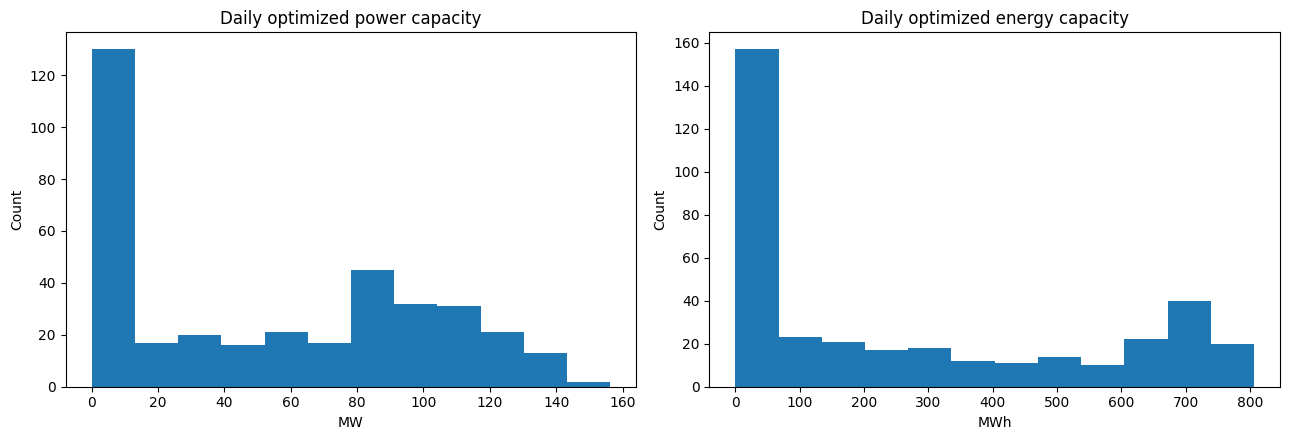

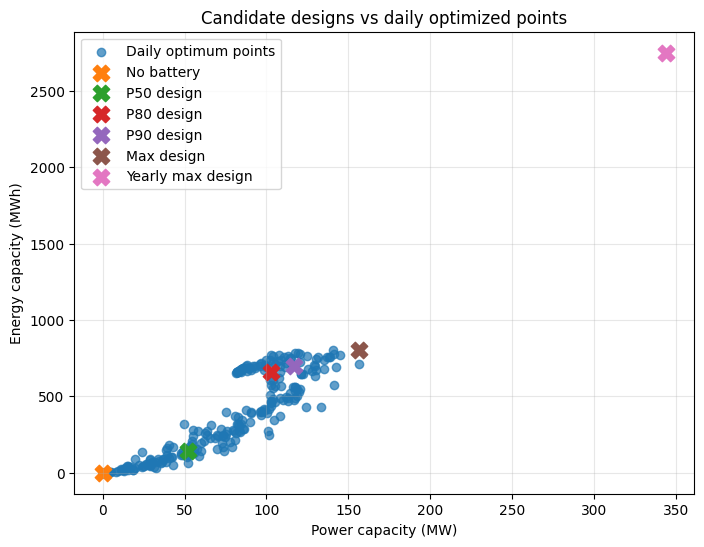

In [5]:
# Histograms of the optimized power and energy capacities across all days
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(results_daily_df["battery_power_capacity_mw"], bins=12)
axes[0].set_title("Daily optimized power capacity")
axes[0].set_xlabel("MW")
axes[0].set_ylabel("Count")

axes[1].hist(results_daily_df["battery_energy_capacity_mwh"], bins=12)
axes[1].set_title("Daily optimized energy capacity")
axes[1].set_xlabel("MWh")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(output_dir / "optimized_capacity_histograms.png", dpi=300)
plt.show()

# Scatter plot of daily optimized points with candidate designs highlighted
plt.figure(figsize=(8, 6))
plt.scatter(
    results_daily_df["battery_power_capacity_mw"],
    results_daily_df["battery_energy_capacity_mwh"],
    alpha=0.7,
    label="Daily optimum points",
)

for _, row in candidates_df.iterrows():
    plt.scatter(row["power_mw"], row["energy_mwh"], s=140, marker="X", label=row["design"])

plt.title("Candidate designs vs daily optimized points")
plt.xlabel("Power capacity (MW)")
plt.ylabel("Energy capacity (MWh)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig(output_dir / "candidate_designs_scatter.png", dpi=300)
plt.show()


Now it is time to evaluate candidates under the point of view of the cost and the sytem performance. To do this, the simulation battery package is needed.

## 7) Run full year simulation for every candidate

To evaluate cost and system performances quickly for each candidate configuration we need to run a simulation with the BESS Simulator class. This will provide the final information to take a decision about the battery sizing.

In [6]:
# needed imports
from src.bess_simulator import Simulator

# needed input paramters

# Solar assumptions
solar_capacity_mw = 300.0
solar_profile = np.array([
    0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
    0.10, 0.30, 0.50, 0.70, 0.85, 0.95,
    0.98, 0.95, 0.88, 0.75, 0.55, 0.30,
    0.10, 0.00, 0.00, 0.00, 0.00, 0.00,
], dtype=float)

# Load assumptions (MW)
demand_mw = np.array([
    50, 45, 40, 38, 36, 38, 45, 60,
    75, 85, 90, 92, 90, 88, 86, 88,
    92, 95, 90, 80, 70, 65, 58, 52,
], dtype=float)

# Battery assumptions
efficiency = 0.90
battery_power_cost = 200_000.0
battery_energy_cost = 300_000.0
max_battery_power = 500.0
max_hours = 8.0

unmet_penalty_cost_per_mwh = 1e9  # set >0 if you want to penalize unmet energy

c:\Users\Pc\Documents\GitHub\optimal-battery-sizing\.venv\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.9) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [7]:
summary_records = []
batch_start = time.perf_counter()
progress_every = 1

n_candidates = len(candidates_df)
n_steps = len(demand_mw)

for idx, candidate in enumerate(candidates_df.to_dict(orient="records"), start=1):
    t0 = time.perf_counter()

    design = candidate["design"]
    battery_power_capacity = float(candidate["power_mw"])
    battery_energy_capacity = float(candidate["energy_mwh"])

    # Run simulation
    model = Simulator(battery_power_capacity, battery_energy_capacity, efficiency=efficiency)
    model.add_solar(capacity=solar_capacity_mw, profile=solar_profile)
    model.add_load(demand=demand_mw)
    model.simulate()
    results = model.get_results()

    # Compute metrics
    unmet = np.asarray(results["unmet"], dtype=float)
    soc = np.asarray(results["s_soc"], dtype=float)
    served = np.maximum(demand_mw - unmet, 0.0)

    total_demand_mwh = float(np.sum(demand_mw))
    total_served_mwh = float(np.sum(served))
    total_unmet_mwh = float(np.sum(unmet))
    reliability_pct = 100.0 * total_served_mwh / total_demand_mwh if total_demand_mwh > 0 else 100.0

    capex_usd = battery_power_capacity * battery_power_cost + battery_energy_capacity * battery_energy_cost
    unmet_penalty_cost_usd = total_unmet_mwh * unmet_penalty_cost_per_mwh
    total_cost_usd = capex_usd + unmet_penalty_cost_usd

    summary_records.append({
        "design": design,
        "sim_hours": n_steps,
        "total_demand_mwh": total_demand_mwh,
        "total_served_mwh": total_served_mwh,
        "total_unmet_mwh": total_unmet_mwh,
        "reliability_pct": reliability_pct,
        "hours_with_unmet": int(np.sum(unmet > 1e-9)),
        "hours_with_unmet_pct": float(100.0 * np.mean(unmet > 1e-9)),
        "capex_usd": float(capex_usd),
        "unmet_penalty_cost_usd": float(unmet_penalty_cost_usd),
        "total_cost_usd": float(total_cost_usd),
        "final_soc_mwh": float(soc[-1]) if len(soc) else 0.0,
        "max_soc_mwh": float(np.max(soc)) if len(soc) else 0.0,
        "max_hourly_unmet_mw": float(np.max(unmet)) if len(unmet) else 0.0,
        "solve_seconds": float(t0 - time.perf_counter()),
    })

    if idx % progress_every == 0 or idx == n_candidates:
        elapsed = time.perf_counter() - batch_start
        print(f"Completed {idx}/{n_candidates} candidates in {elapsed:.1f}s | latest: {design}")

simulation_summary_df = pd.DataFrame(summary_records)

Completed 1/6 candidates in 0.0s | latest: No battery
Completed 2/6 candidates in 0.0s | latest: P50 design
Completed 3/6 candidates in 0.0s | latest: P80 design
Completed 4/6 candidates in 0.0s | latest: P90 design
Completed 5/6 candidates in 0.0s | latest: Max design
Completed 6/6 candidates in 0.0s | latest: Yearly max design


## 8) Final decision table



In [8]:
simulation_summary_df

,design,sim_hours,total_demand_mwh,total_served_mwh,total_unmet_mwh,reliability_pct,hours_with_unmet,hours_with_unmet_pct,capex_usd,unmet_penalty_cost_usd,total_cost_usd,final_soc_mwh,max_soc_mwh,max_hourly_unmet_mw,solve_seconds
0,No battery,24,1648.0,996.00,652.00,60.436893,14,58.333333,0.000000e+00,6.520000e+11,6.520000e+11,0.000000,0.000000,80.0,-0.000420
1,P50 design,24,1648.0,1129.47,518.53,68.535801,13,54.166667,5.260692e+07,5.185300e+11,5.185826e+11,0.000000,140.689733,65.0,-0.000360
2,P80 design,24,1648.0,1386.00,262.00,84.101942,7,29.166667,2.175752e+08,2.620000e+11,2.622176e+11,245.687892,656.783988,50.0,-0.000278
3,P90 design,24,1648.0,1386.00,262.00,84.101942,7,29.166667,2.336978e+08,2.620000e+11,2.622337e+11,289.896534,700.992630,50.0,-0.000216
4,Max design,24,1648.0,1386.00,262.00,84.101942,7,29.166667,2.732059e+08,2.620000e+11,2.622732e+11,395.390117,806.486213,50.0,-0.000312
5,Yearly max design,24,1648.0,1386.00,262.00,84.101942,7,29.166667,8.938000e+08,2.620000e+11,2.628938e+11,895.240806,1306.336901,50.0,-0.000213


In [12]:
kpi_cols = [
    "total_demand_mwh",
    "total_served_mwh",
    "total_unmet_mwh",
    "reliability_pct",
    "hours_with_unmet",
    "hours_with_unmet_pct",
    "capex_usd",
    "unmet_penalty_cost_usd",
    "total_cost_usd",
    "max_soc_mwh",
    "max_hourly_unmet_mw",
]

screen_df = simulation_summary_df.sort_values(
    ["reliability_pct", "total_cost_usd", "total_unmet_mwh"],
    ascending=[False, True, True],
).reset_index(drop=True)

# add candidate design information to the summary dataframe
screen_df = screen_df.merge(
    candidates_df[["design", "power_mw", "energy_mwh", "duration_h"]],
    on="design",
    how="left",
)

print("Completed simulation for all candidate designs.")
display(screen_df)

# save the summary dataframe to a CSV file
summary_csv_path = output_dir / "candidate_designs_summary.csv"
screen_df.to_csv(summary_csv_path, index=False)

Completed simulation for all candidate designs.


,design,sim_hours,total_demand_mwh,total_served_mwh,total_unmet_mwh,reliability_pct,hours_with_unmet,hours_with_unmet_pct,capex_usd,unmet_penalty_cost_usd,total_cost_usd,final_soc_mwh,max_soc_mwh,max_hourly_unmet_mw,solve_seconds,power_mw,energy_mwh,duration_h
0,P80 design,24,1648.0,1386.00,262.00,84.101942,7,29.166667,2.175752e+08,2.620000e+11,2.622176e+11,245.687892,656.783988,50.0,-0.000278,102.7,656.783988,6.395170
1,P90 design,24,1648.0,1386.00,262.00,84.101942,7,29.166667,2.336978e+08,2.620000e+11,2.622337e+11,289.896534,700.992630,50.0,-0.000216,117.0,700.992630,5.991390
2,Max design,24,1648.0,1386.00,262.00,84.101942,7,29.166667,2.732059e+08,2.620000e+11,2.622732e+11,395.390117,806.486213,50.0,-0.000312,156.3,806.486213,5.159861
3,Yearly max design,24,1648.0,1386.00,262.00,84.101942,7,29.166667,8.938000e+08,2.620000e+11,2.628938e+11,895.240806,1306.336901,50.0,-0.000213,344.0,2750.000000,7.994186
4,P50 design,24,1648.0,1129.47,518.53,68.535801,13,54.166667,5.260692e+07,5.185300e+11,5.185826e+11,0.000000,140.689733,65.0,-0.000360,52.0,140.689733,2.705572
5,No battery,24,1648.0,996.00,652.00,60.436893,14,58.333333,0.000000e+00,6.520000e+11,6.520000e+11,0.000000,0.000000,80.0,-0.000420,0.0,0.000000,0.000000


The first 4 designs have same reliability, and therefore same effect on the unmet energy, which is the main driver of the total cost.
The choice therefore comes down to the tradeoff between capex and unmet penalty cost, which is driven by the battery sizing. 
Between the first 4 designs, the P80 design is the most cost-effective, and therefore the best choice. The P90 design is more expensive, but does not provide any additional reliability benefit. The Max design is even more expensive, and also does not provide any additional reliability benefit. The Yearly max design is the most expensive, and also does not provide any additional reliability benefit.
 


In [10]:
# print the best configuration based on reliability and cost
best_design = screen_df.iloc[0]
print(f"Best candidate design: {best_design['design']}")

print(f"\nEnergy Capacity: {best_design['energy_mwh']:,.2f} MWh")
print(f"Power Capacity: {best_design['power_mw']:,.2f} MW")

print(f"\nReliability: {best_design['reliability_pct']:.2f}%")
print(f"Capex USD: ${best_design['capex_usd']:,.2f}")
print(f"Total Unmet Demand: {best_design['total_unmet_mwh']:.2f} MWh")


Best candidate design: P80 design

Energy Capacity: 656.78 MWh
Power Capacity: 102.70 MW

Reliability: 84.10%
Capex USD: $217,575,196.45
Total Unmet Demand: 262.00 MWh


The final best battery configuration that can be derived with the current tool and given the input parameters is the P80 candidate with 
- Energy capacity: 657 MWh
- Power capacity: 103 MW

## 9) Optional comparison plots

These plots keep the visual output compact while still helping compare candidates:
- CAPEX vs reliability,
- daily unmet-load distribution by candidate.

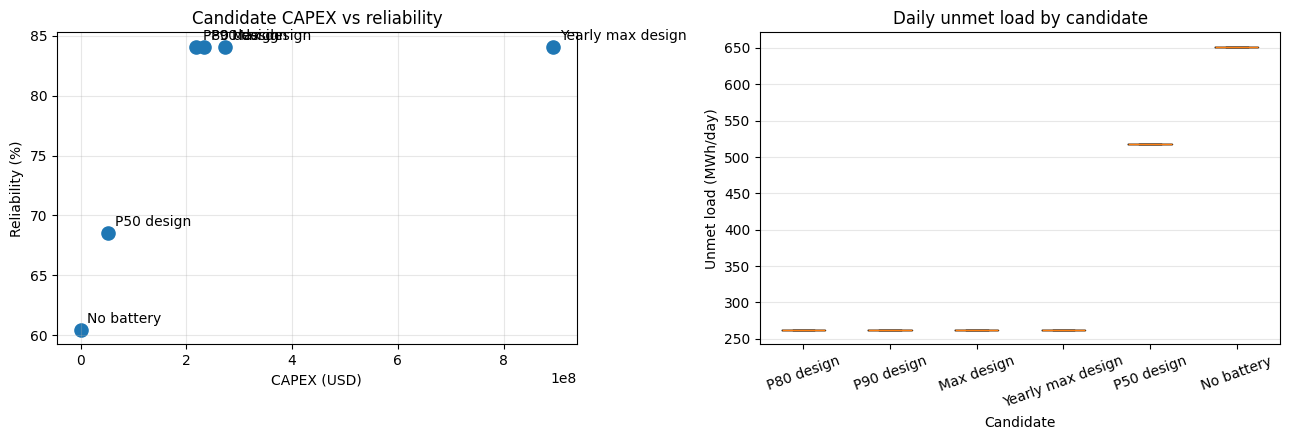

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(screen_df["capex_usd"], screen_df["reliability_pct"], s=90)
for _, row in screen_df.iterrows():
    axes[0].annotate(row["design"], (row["capex_usd"], row["reliability_pct"]), xytext=(5, 5), textcoords="offset points")
axes[0].set_title("Candidate CAPEX vs reliability")
axes[0].set_xlabel("CAPEX (USD)")
axes[0].set_ylabel("Reliability (%)")
axes[0].grid(True, alpha=0.3)

plot_data = [
    screen_df.loc[screen_df["design"] == design, "total_unmet_mwh"].to_numpy()
    for design in screen_df["design"]
]
axes[1].boxplot(plot_data, tick_labels=screen_df["design"], showfliers=False)
axes[1].set_title("Daily unmet load by candidate")
axes[1].set_xlabel("Candidate")
axes[1].set_ylabel("Unmet load (MWh/day)")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / "candidate_designs_summary.png", dpi=300)
plt.show()

This notebook demonstrates the importance of simulation-based approaches for optimal battery sizing. If the battery had been sized solely based on the optimization results from Notebook 02, the selected design would have either been a severely oversized battery (based on the yearly optimization) or, alternatively, a very large battery (based on the largest design from the daily optimization), both of which would result in unnecessarily high costs.